# Career Path Prediction System
### GPI Internship - Cloud Counselage

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow import keras

print('All libraries loaded!')

All libraries loaded!


## Step 1 - Load the Data

In [3]:
df = pd.read_csv('PS2_Dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (6901, 20)


,Logical quotient rating,hackathons,coding skills rating,public speaking points,self-learning capability?,Extra-courses did,certifications,workshops,reading and writing skills,memory capability score,Interested subjects,interested career area,Type of company want to settle in?,Taken inputs from seniors or elders,Interested Type of Books,Management or Technical,hard/smart worker,worked in teams ever?,Introvert,Suggested Job Role
0,5,0,6,2,yes,no,information security,testing,poor,poor,programming,testing,BPA,no,Series,Management,smart worker,yes,no,Applications Developer
1,7,6,4,3,no,yes,shell programming,testing,excellent,medium,Management,system developer,Cloud Services,yes,Autobiographies,Technical,hard worker,no,yes,Applications Developer
2,2,3,9,1,no,yes,information security,testing,excellent,poor,data engineering,Business process analyst,product development,yes,Travel,Technical,smart worker,no,no,Applications Developer
3,2,6,3,5,no,yes,r programming,database security,excellent,poor,networks,testing,Testing and Maintainance Services,yes,Guide,Management,smart worker,yes,yes,Applications Developer
4,2,0,3,4,yes,no,distro making,game development,excellent,medium,Software Engineering,system developer,BPA,no,Health,Technical,hard worker,yes,no,Applications Developer


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6901 entries, 0 to 6900
Data columns (total 20 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   Logical quotient rating              6901 non-null   int64 
 1   hackathons                           6901 non-null   int64 
 2   coding skills rating                 6901 non-null   int64 
 3   public speaking points               6901 non-null   int64 
 4   self-learning capability?            6901 non-null   object
 5   Extra-courses did                    6901 non-null   object
 6   certifications                       6901 non-null   object
 7   workshops                            6901 non-null   object
 8   reading and writing skills           6901 non-null   object
 9   memory capability score              6901 non-null   object
 10  Interested subjects                  6901 non-null   object
 11  interested career area               6901 n

In [5]:
df.isnull().sum()

Logical quotient rating                0
hackathons                             0
coding skills rating                   0
public speaking points                 0
self-learning capability?              0
Extra-courses did                      0
certifications                         0
workshops                              0
reading and writing skills             0
memory capability score                0
Interested subjects                    0
interested career area                 0
Type of company want to settle in?     0
Taken inputs from seniors or elders    0
Interested Type of Books               0
Management or Technical                0
hard/smart worker                      0
worked in teams ever?                  0
Introvert                              0
Suggested Job Role                     0
dtype: int64

## Step 2 - EDA (Exploratory Data Analysis)

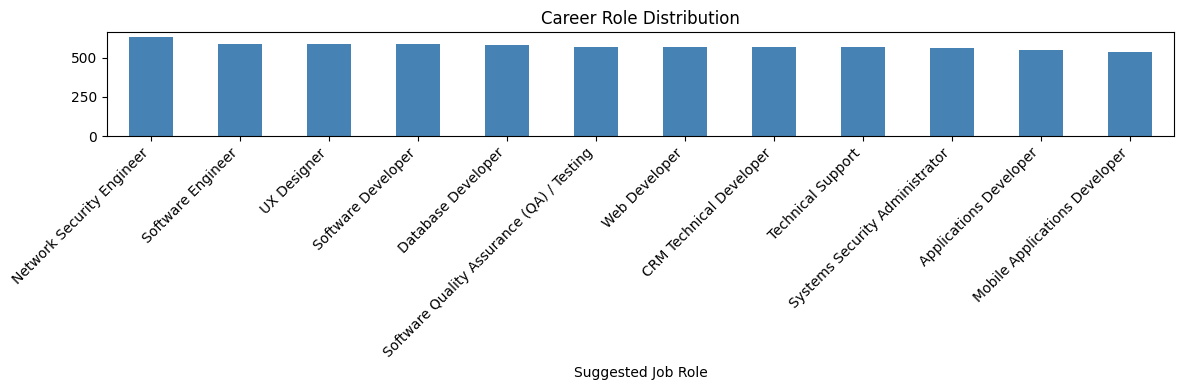

In [7]:
df['Suggested Job Role'].value_counts().plot(kind='bar', color='steelblue', figsize=(12,4))
plt.title('Career Role Distribution')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

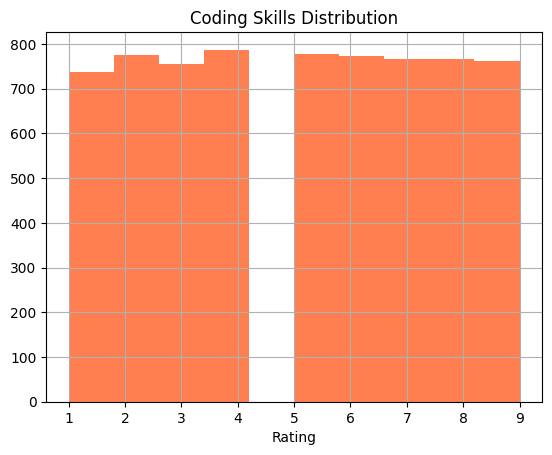

In [8]:
df['coding skills rating'].hist(bins=10, color='coral')
plt.title('Coding Skills Distribution')
plt.xlabel('Rating')
plt.show()

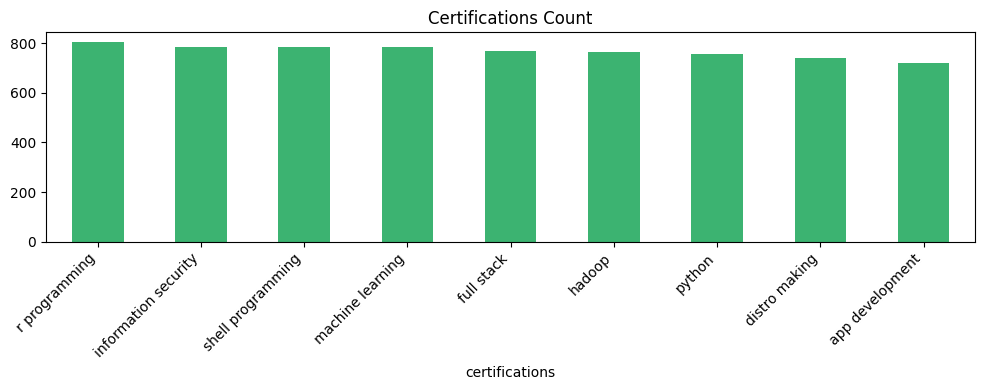

In [9]:
df['certifications'].value_counts().plot(kind='bar', color='mediumseagreen', figsize=(10,4))
plt.title('Certifications Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

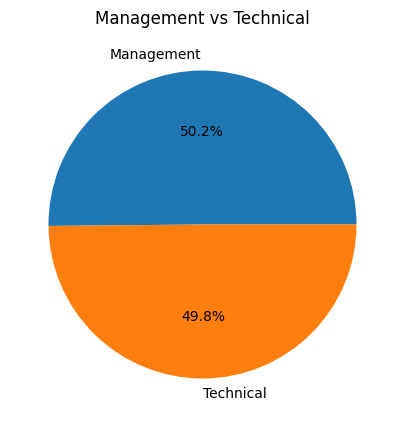

In [10]:
df['Management or Technical'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(5,5))
plt.title('Management vs Technical')
plt.ylabel('')
plt.show()

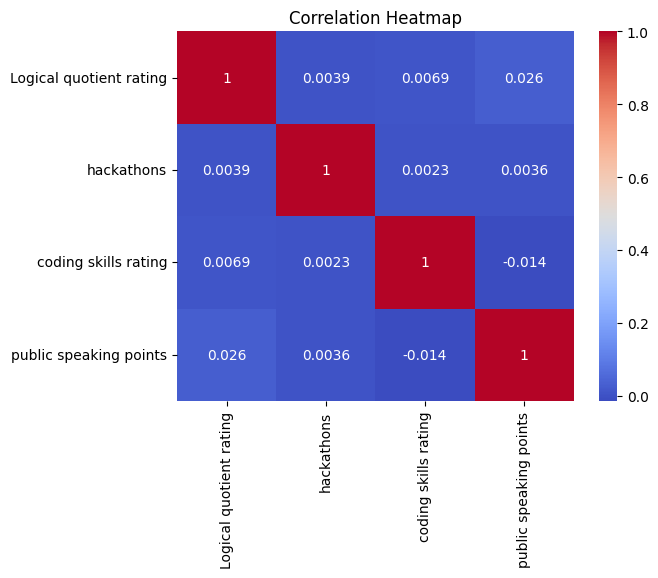

In [11]:
num_cols = ['Logical quotient rating', 'hackathons', 'coding skills rating', 'public speaking points']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Step 3 - Data Preprocessing

In [22]:
df_encoded = df.copy()
label_encoders = {}

for col in df.columns:
    if df[col].dtype == object or str(df[col].dtype) == 'str':
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

print('Encoding done!')
df_encoded.head()

Encoding done!


,Logical quotient rating,hackathons,coding skills rating,public speaking points,self-learning capability?,Extra-courses did,certifications,workshops,reading and writing skills,memory capability score,Interested subjects,interested career area,Type of company want to settle in?,Taken inputs from seniors or elders,Interested Type of Books,Management or Technical,hard/smart worker,worked in teams ever?,Introvert,Suggested Job Role
0,5,0,6,2,1,0,4,6,2,2,9,5,0,0,28,0,1,1,0,0
1,7,6,4,3,0,1,8,6,0,1,2,4,1,1,3,1,0,0,1,0
2,2,3,9,1,0,1,4,6,0,2,5,0,9,1,29,1,1,0,0,0
3,2,6,3,5,0,1,7,2,0,2,7,5,7,1,13,0,1,1,1,0
4,2,0,3,4,1,0,1,3,0,1,3,4,0,0,14,1,0,1,0,0


In [23]:
X = df_encoded.drop('Suggested Job Role', axis=1).values.astype(float)
y = df_encoded['Suggested Job Role'].values.astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (5520, 19)
Test size: (1381, 19)


## Step 4 - Machine Learning Model (Random Forest)

In [27]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [28]:
rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
print('Random Forest Accuracy:', round(rf_acc * 100, 2), '%')

Random Forest Accuracy: 8.11 %


In [30]:
classes = label_encoders['Suggested Job Role'].classes_
print(classification_report(y_test, rf_pred, target_names=classes))

                                           precision    recall  f1-score   support

                   Applications Developer       0.06      0.04      0.05       132
                  CRM Technical Developer       0.09      0.10      0.10       105
                       Database Developer       0.10      0.10      0.10       123
            Mobile Applications Developer       0.08      0.07      0.07       100
                Network Security Engineer       0.07      0.11      0.09       121
                       Software Developer       0.07      0.06      0.06       113
                        Software Engineer       0.06      0.07      0.06       116
Software Quality Assurance (QA) / Testing       0.10      0.08      0.09       118
           Systems Security Administrator       0.07      0.07      0.07       114
                        Technical Support       0.08      0.08      0.08       111
                              UX Designer       0.11      0.10      0.10       119
   

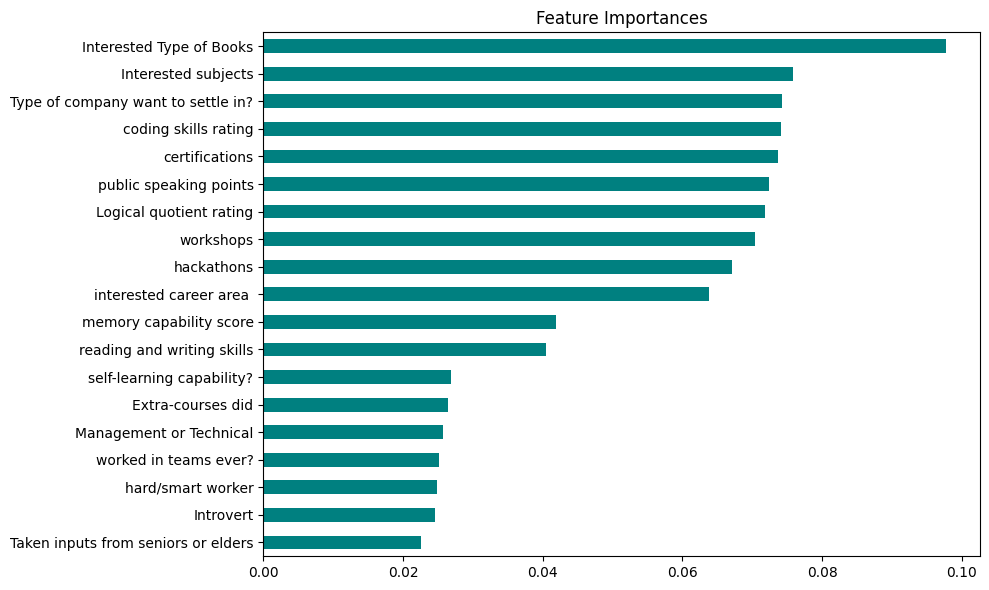

In [33]:
feature_names  = df.drop('Suggested Job Role', axis=1).columns
importances    = pd.Series(rf.feature_importances_, index=feature_names)
importances.sort_values().plot(kind='barh', figsize=(10,6), color='teal')
plt.title('Feature Importances')
plt.tight_layout()
plt.show()

## Step 5 - Deep Learning Model (Neural Network)
A simple 3-layer neural network:
- Layer 1: 64 neurons, ReLU  
- Layer 2: 32 neurons, ReLU  
- Output : 12 neurons, Softmax (one per career)

In [36]:
num_classes = len(np.unique(y))

nn_model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(num_classes, activation='softmax')
])

nn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 12)                  │             396 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,756 (14.67 KB)

 Trainable params: 3,756 (14.67 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history = nn_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.0811 - loss: 2.7205 - val_accuracy: 0.0707 - val_loss: 2.5438
Epoch 2/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0843 - loss: 2.4970 - val_accuracy: 0.0797 - val_loss: 2.5059
Epoch 3/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.0972 - loss: 2.4825 - val_accuracy: 0.0688 - val_loss: 2.4997
Epoch 4/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1069 - loss: 2.4782 - val_accuracy: 0.0833 - val_loss: 2.5023
Epoch 5/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1079 - loss: 2.4737 - val_accuracy: 0.0670 - val_loss: 2.4988
Epoch 6/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1125 - loss: 2.4690 - val_accuracy: 0.0851 - val_loss: 2.5034
Epoch 7/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1161 - loss: 2.4659 - val_accuracy: 0.0652 - val_loss: 2.5039
Epoch 8/20
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1127 - loss: 2.4617 - val_accuracy: 0

In [40]:
nn_loss, nn_acc = nn_model.evaluate(X_test, y_test, verbose=0)
print('Neural Network Accuracy:', round(nn_acc * 100, 2), '%')

Neural Network Accuracy: 8.4 %


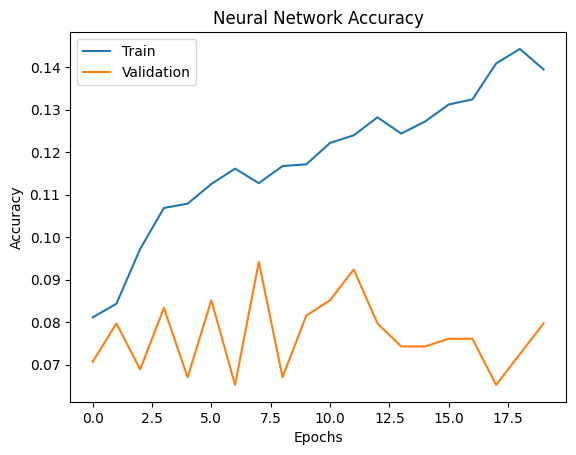

In [41]:
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Neural Network Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Step 6 - Compare Both Models

Random Forest Accuracy : 8.11 %
Neural Network Accuracy: 8.4 %


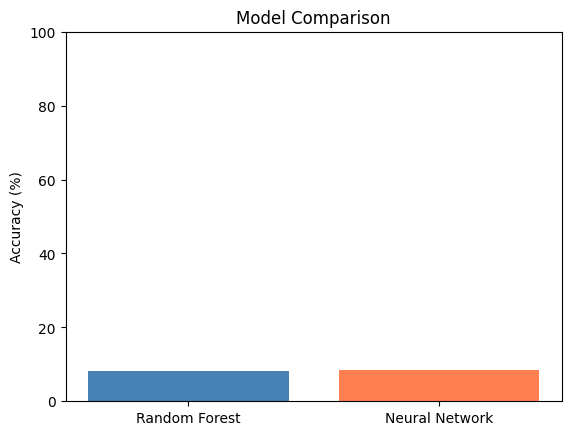

In [45]:
print('Random Forest Accuracy :', round(rf_acc  * 100, 2), '%')
print('Neural Network Accuracy:', round(nn_acc  * 100, 2), '%')

plt.bar(['Random Forest', 'Neural Network'], [rf_acc*100, nn_acc*100], color=['steelblue', 'coral'])
plt.title('Model Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.show()

## Step 7 - Save the Model

In [48]:
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

feature_columns = df.drop('Suggested Job Role', axis=1).columns.tolist()
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(feature_columns, f)

print('Model saved successfully!')

Model saved successfully!
